# Model 2: MuRIL — Multilingual Representations for Indian Languages
## Cross-Lingual Transfer: Hinglish → Hindi / English / Combined

**Model:** `google/muril-base-cased`  
**Why MuRIL?** Google's MuRIL is trained on 17 Indian languages + their transliterated forms.
It explicitly includes Hinglish-style transliterated data in pretraining.
Expected to outperform XLM-RoBERTa on Hindi transfer and match it on English.

**Key comparison:** MuRIL vs XLM-RoBERTa on the same 3 test sets.


## Step 0: Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q --force-reinstall \
  transformers==4.44.2 \
  accelerate==0.33.0 \
  datasets==2.19.0

print("Done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 243.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.6 MB/s eta 0:00

## Step 1: Setup

In [ ]:
import os,re,json,random,warnings
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns
import torch
from torch import nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,f1_score
from transformers import (AutoTokenizer,AutoModelForSequenceClassification,
                           TrainingArguments,Trainer,EarlyStoppingCallback,set_seed)
from datasets import Dataset as HFDataset,DatasetDict
warnings.filterwarnings('ignore')
SEED=42;set_seed(SEED);random.seed(SEED);np.random.seed(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN=128;BATCH_SIZE=16;EPOCHS=5;LR=2e-5;NUM_LABELS=2
LABEL_MAP={0:"Non-Hate",1:"Hate"}
OUTPUT_DIR="/content/drive/MyDrive/muril_results"
Path(OUTPUT_DIR).mkdir(parents=True,exist_ok=True)
MODEL_NAME="google/muril-base-cased"
print(f"Device:{DEVICE} | Model:{MODEL_NAME}")

Device:cuda | Model:google/muril-base-cased


## Step 2: Normalization Module (same as Model 1)

In [ ]:
SLANG={
    r'\bbc\b':'bhenchod',r'\bmc\b':'madarchod',r'\bbkl\b':'bhosadike',
    r'\bbsdk\b':'bhosadike',r'\bch[ou]tiy[ae]?\b':'chutiya',r'\bchutia\b':'chutiya',
    r'\bsaale?\b':'saala',r'\bkamine[y]?\b':'kamina',r'\bkutt[ey]?\b':'kutta',
    r'\bgand[uu]?\b':'gandu',r'\bharami[i]?\b':'harami',r'\bbhench[o0]d\b':'bhenchod',
    r'\brandi\b':'randi',r'\bnalayak\b':'nalayak',r'\bghati[y]?a\b':'ghatiya',
    r'\bneech\b':'neech',r'\bgawar\b':'gawar',r'\bnafrat\b':'nafrat',
    r'\bnhi\b':'nahi',r'\bnai\b':'nahi',r'\bkl\b':'kal',r'\bkyu\b':'kyun',
    r'\blol\b':'laughing',r'\bwtf\b':'what the hell',
}
TRANSLIT={
    r'\bkyaa\b':'kya',r'\bnahin\b':'nahi',r'\bnaheen\b':'nahi',
    r'\bbhaut\b':'bahut',r'\bbohat\b':'bahut',r'\bbohot\b':'bahut',
    r'\bterii\b':'teri',r'\bmujhey\b':'mujhe',r'\byar\b':'yaar',
    r'\bachha\b':'accha',r'\bacha\b':'accha',
}
class HinglishNormalizer:
    def normalize(self,text):
        t=text.lower().strip()
        t=re.sub(r'http\S+|www\.\S+','',t)
        t=re.sub(r'@\w+','[USER]',t);t=re.sub(r'#(\w+)',r'\1',t)
        t=re.sub(r'([!?.])\1{2,}',r'\1',t);t=re.sub(r'^rt\s+','',t)
        t=re.sub(r'(.)\1{2,}',r'\1\1',t)
        for p,v in TRANSLIT.items(): t=re.sub(p,v,t,flags=re.IGNORECASE)
        for p,v in SLANG.items(): t=re.sub(p,v,t,flags=re.IGNORECASE)
        return re.sub(r'\s+',' ',t).strip()
    def normalize_batch(self,texts): return [self.normalize(t) for t in texts]
    def augment(self,texts,labels):
        n=self.normalize_batch(texts)
        return list(texts)+n,list(labels)+list(labels)
normalizer=HinglishNormalizer()
print("Normalizer ready")

Normalizer ready


## Step 3: Load Data (same demo or upload CSVs)

In [ ]:
## Step 3: Load Data from Kaggle

import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split

# ================= HINGLISH (TRAIN) =================
path = kagglehub.dataset_download("sharduldhekane/code-mixed-hinglish-hate-speech-detection-dataset")
df = pd.read_csv(f"{path}/combined_hate_speech_dataset.csv")

if 'tweet' in df.columns:
    df = df.rename(columns={'tweet': 'text'})
if 'class' in df.columns:
    df = df.rename(columns={'class': 'label'})
if 'hate_label' in df.columns:
    df = df.rename(columns={'hate_label': 'label'})

df_train_raw = df[['text','label']].dropna().drop_duplicates().sample(frac=1, random_state=SEED).reset_index(drop=True)

# ================= HINDI (TEST) =================
path_hi = kagglehub.dataset_download("harithapliyal/hate-speech-in-hindi")
df_hi = pd.read_csv(os.path.join(path_hi, "Hatespeech-Hindi_Train.csv"))
df_hi = df_hi.rename(columns={'Post': 'text', 'Labels Set': 'label'})

def convert_label(x):
    x = str(x).lower()
    return 0 if 'non-hostile' in x else 1

df_hi['label'] = df_hi['label'].apply(convert_label)
df_hindi = df_hi[['text','label']].dropna().drop_duplicates().reset_index(drop=True)

# ================= ENGLISH (TEST) =================
path_en = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")
file_en = [f for f in os.listdir(path_en) if f.endswith('.csv')][0]
df_en = pd.read_csv(os.path.join(path_en, file_en))
df_en = df_en.rename(columns={'tweet': 'text', 'class': 'label'})
df_en['label'] = df_en['label'].apply(lambda x: 1 if x in [0,1] else 0)
df_english = df_en[['text','label']].dropna().drop_duplicates().reset_index(drop=True)

# ================= TRAIN/TEST SPLIT =================
df_train_raw, df_hinglish_test = train_test_split(
    df_train_raw, test_size=0.15, stratify=df_train_raw['label'], random_state=SEED
)

# ================= COMBINED (TEST) =================
df_combined = pd.concat([
    df_hinglish_test,
    df_hindi.sample(min(500, len(df_hindi)), random_state=SEED),
    df_english.sample(min(500, len(df_english)), random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# ================= PRINT =================
print(f"Train (Hinglish): {len(df_train_raw)} | H:{sum(df_train_raw['label']==1)} N:{sum(df_train_raw['label']==0)}")
print(f"Test  (Hinglish held-out): {len(df_hinglish_test)}")
print(f"Test  (Hindi)   : {len(df_hindi)}")
print(f"Test  (English) : {len(df_english)}")
print(f"Test  (Combined): {len(df_combined)}")

100%|██████████| 2.17M/2.17M [00:00<00:00, 54.8MB/s]

Extracting files...


100%|██████████| 0.99M/0.99M [00:00<00:00, 123MB/s]

Extracting files...


100%|██████████| 1.01M/1.01M [00:00<00:00, 111MB/s]

Extracting files...
Train (Hinglish): 25109 | H:11663 N:13446
Test  (Hinglish held-out): 4432
Test  (Hindi)   : 5718
Test  (English) : 24783
Test  (Combined): 5432


In [ ]:
print("df_train_raw shape:", df_train_raw.shape)
print("df_train_raw label counts:\n", df_train_raw['label'].value_counts())
print("\nFirst few rows:")
print(df_train_raw.head())
print("\nLabel dtype:", df_train_raw['label'].dtype)
print("Unique labels:", df_train_raw['label'].unique())

print("df_hindi shape:", df_hindi.shape)
print("df_english shape:", df_english.shape)

df_train_raw shape: (25109, 2)
df_train_raw label counts:
 label
0    13446
1    11663
Name: count, dtype: int64

First few rows:
                                                    text  label
6925   stop when you really know you are too stupid t...      1
20153  fuck you last suck on a fat member fagot mothe...      1
17700  यदि वे निचली जात के लोग हैं तो उनके दिमाग पक्क...      1
26113   से ग्राम पंचायत कपसा में लगभग  लाख  हजार रुपए...      0
2101   Sir ji I am sure chillane se kuchh valid nahi ...      0

Label dtype: int64
Unique labels: [1 0]
df_hindi shape: (5718, 2)
df_english shape: (24783, 2)


## Step 4: Augment + Split

In [ ]:
aug_t,aug_l=normalizer.augment(df_train_raw['text'].tolist(),df_train_raw['label'].tolist())
df_aug=pd.DataFrame({'text':aug_t,'label':aug_l}).sample(frac=1,random_state=SEED).reset_index(drop=True)
df_tr,df_dev=train_test_split(df_aug,test_size=0.15,stratify=df_aug['label'],random_state=SEED)
print(f"Train:{len(df_tr)} | Dev:{len(df_dev)}")

Train:42685 | Dev:7533


## Step 5: Train MuRIL

> MuRIL is pretrained on 17 Indian languages including transliterated Hindi.
> It understands Hinglish code-mixing better than generic XLM-RoBERTa.

In [ ]:
def get_cw(df):
    c=df['label'].value_counts().sort_index().values.astype(float)
    w=1.0/c;w=w/w.sum()*len(c);return torch.tensor(w,dtype=torch.float)
def tok_ds(tr,dv,te,tok):
    def fn(b): return tok(b['text'],truncation=True,padding='max_length',max_length=MAX_LEN)
    ds=DatasetDict({'train':HFDataset.from_pandas(tr[['text','label']]),
                    'validation':HFDataset.from_pandas(dv[['text','label']]),
                    'test':HFDataset.from_pandas(te[['text','label']])})
    ds=ds.map(fn,batched=True,remove_columns=['text'])
    ds=ds.rename_column('label','labels');ds.set_format('torch');return ds
class WTrainer(Trainer):
    def __init__(self,cw,*a,**k): super().__init__(*a,**k);self.cw=cw.to(DEVICE)
    # NEW - compatible with transformers 4.44.x
    def compute_loss(self, m, inp, num_items_in_batch=None, **k):
      return_outputs = k.pop('return_outputs', False)
      lb = inp.pop('labels'); o = m(**inp)
      loss = nn.CrossEntropyLoss(weight=self.cw)(o.logits, lb)
      return (loss, o) if return_outputs else loss
def cm_fn(ep):
    p=np.argmax(ep.predictions,axis=-1)
    return {'macro_f1':f1_score(ep.label_ids,p,average='macro')}

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
for param in model.parameters():
    param.data = param.data.contiguous()
ds=tok_ds(df_tr,df_dev,df_dev,tokenizer)
args=TrainingArguments(output_dir=f"{OUTPUT_DIR}/ckpt",num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,warmup_steps=200,weight_decay=0.01,
    eval_strategy='epoch',save_strategy='epoch',load_best_model_at_end=True,
    metric_for_best_model='macro_f1',greater_is_better=True,
    fp16=torch.cuda.is_available(),seed=SEED,report_to='none',save_total_limit=1)
trainer=WTrainer(get_cw(df_tr),model=model,args=args,
                  train_dataset=ds['train'],eval_dataset=ds['validation'],
                  compute_metrics=cm_fn,callbacks=[EarlyStoppingCallback(2)])
trainer.train()
# NEW
# Fix non-contiguous tensors before saving
for param in model.parameters():
    param.data = param.data.contiguous()

trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")
print("MuRIL training complete")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/42685 [00:00<?, ? examples/s]

Map:   0%|          | 0/7533 [00:00<?, ? examples/s]

Map:   0%|          | 0/7533 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,0.499200,0.521358,0.753455
2,0.363400,0.416571,0.824692
3,0.232800,0.421907,0.852947
4,0.191500,0.403909,0.886352
5,0.143900,0.423709,0.896564


MuRIL training complete


## Step 6: Evaluate on 3 Test Sets

In [ ]:
def evaluate_on(model,tokenizer,df_test,name):
    model.eval();preds=[]
    for text in df_test['text'].tolist():
        enc=tokenizer(str(text),return_tensors='pt',truncation=True,padding=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad(): logits=model(**enc).logits
        preds.append(torch.argmax(logits).item())
    true=df_test['label'].tolist()
    rpt=classification_report(true,preds,target_names=list(LABEL_MAP.values()),output_dict=True)
    print(f"\n[{name}]"); print(classification_report(true,preds,target_names=list(LABEL_MAP.values())))
    return {'dataset':name,'macro_f1':round(rpt['macro avg']['f1-score'],4),
            'weighted_f1':round(rpt['weighted avg']['f1-score'],4),
            'precision':round(rpt['macro avg']['precision'],4),
            'recall':round(rpt['macro avg']['recall'],4),
            'preds':np.array(preds),'true':np.array(true)}

r_h=evaluate_on(model,tokenizer,df_hindi,"Hindi")
r_e=evaluate_on(model,tokenizer,df_english,"English")
r_c=evaluate_on(model,tokenizer,df_combined,"Combined")
all_results=[r_h,r_e,r_c]
rdf=pd.DataFrame([{k:v for k,v in r.items() if k not in ['preds','true']} for r in all_results])
print("\nMuRIL Results:"); print(rdf[['dataset','macro_f1','weighted_f1']].to_string(index=False))
rdf.to_csv(f"{OUTPUT_DIR}/muril_results.csv",index=False)


[Hindi]
              precision    recall  f1-score   support

    Non-Hate       0.55      0.60      0.57      3050
        Hate       0.49      0.43      0.46      2668

    accuracy                           0.52      5718
   macro avg       0.52      0.52      0.52      5718
weighted avg       0.52      0.52      0.52      5718


[English]
              precision    recall  f1-score   support

    Non-Hate       0.18      0.61      0.28      4163
        Hate       0.85      0.44      0.58     20620

    accuracy                           0.47     24783
   macro avg       0.51      0.52      0.43     24783
weighted avg       0.73      0.47      0.53     24783


[Combined]
              precision    recall  f1-score   support

    Non-Hate       0.66      0.73      0.69      2728
        Hate       0.69      0.62      0.65      2704

    accuracy                           0.67      5432
   macro avg       0.68      0.67      0.67      5432
weighted avg       0.68      0.67      0.6

## Step 7: XAI Analysis

[Hindi] AOPC Raw:0.0006 Norm:-0.0068 Δ=-0.0073
[English] AOPC Raw:0.0156 Norm:0.0111 Δ=-0.0044
[Combined] AOPC Raw:-0.0052 Norm:-0.0137 Δ=-0.0084


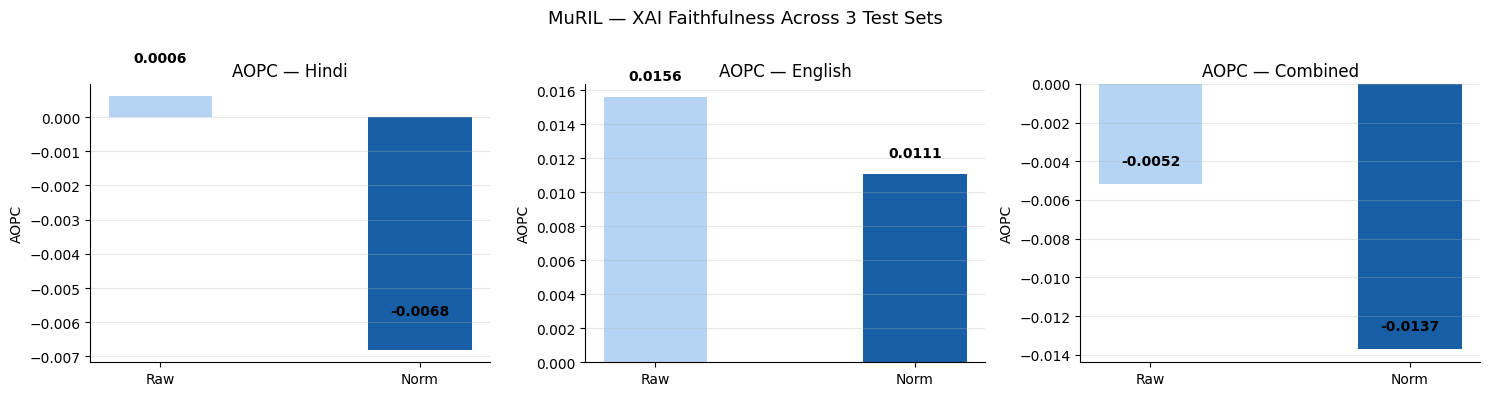

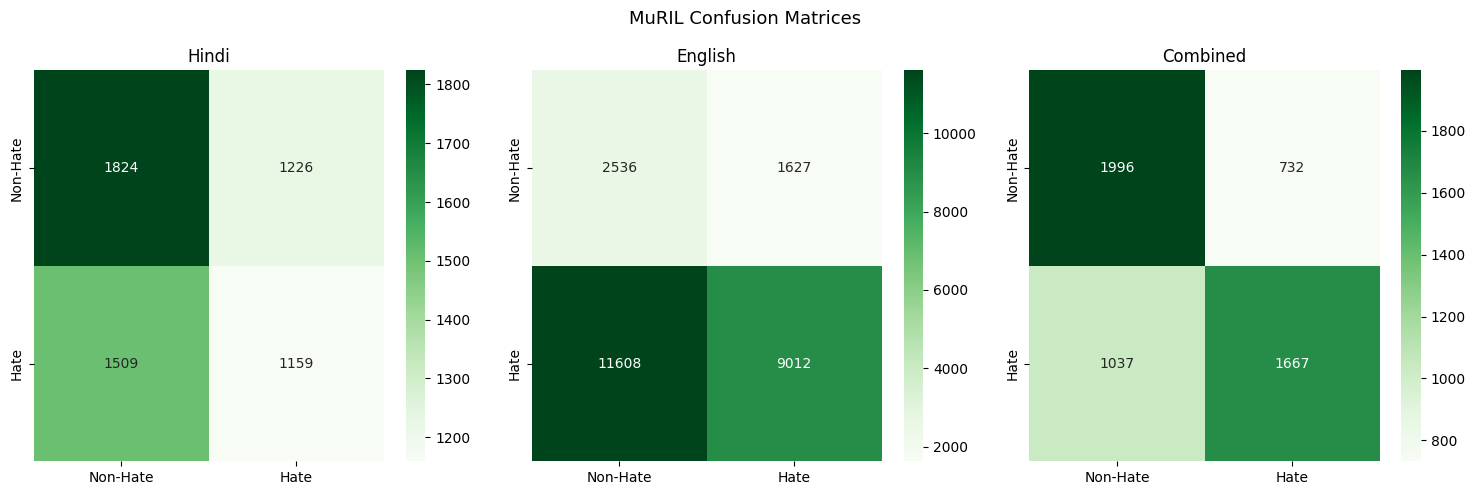

In [ ]:
def pred_fn(texts):
    model.eval();all_p=[]
    for i in range(0,len(texts),8):
        enc=tokenizer(list(texts[i:i+8]),return_tensors='pt',truncation=True,padding=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad(): logits=model(**enc).logits
        all_p.extend(torch.softmax(logits,-1).cpu().numpy())
    return np.array(all_p)

def aopc(texts,n=5):
    drops=[]
    for t in texts:
        toks=t.split()
        if len(toks)<3: continue
        orig=pred_fn([t])[0].max();step=max(1,len(toks)//n);cum=0.0;rem=toks.copy()
        for _ in range(n):
            if not rem: break
            rem=rem[:-step]
            cum+=float(orig-pred_fn([' '.join(rem) if rem else '[MASK]'])[0].max())
        drops.append(cum/n)
    return float(sum(drops)/len(drops)) if drops else 0.0

xai_rows=[]
for df_t,name in [(df_hindi,'Hindi'),(df_english,'English'),(df_combined,'Combined')]:
    txts=df_t['text'].head(15).tolist()
    ntxts=normalizer.normalize_batch(txts)
    ar,an=aopc(txts),aopc(ntxts)
    xai_rows.append({'dataset':name,'aopc_raw':round(ar,4),'aopc_norm':round(an,4),'delta':round(an-ar,4)})
    print(f"[{name}] AOPC Raw:{ar:.4f} Norm:{an:.4f} Δ={an-ar:+.4f}")

pd.DataFrame(xai_rows).to_csv(f"{OUTPUT_DIR}/muril_xai.csv",index=False)

fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,row in zip(axes,xai_rows):
    ar,an=row['aopc_raw'],row['aopc_norm']
    bars=ax.bar(['Raw','Norm'],[ar,an],color=['#B5D4F4','#185FA5'],width=0.4)
    for bar,v in zip(bars,[ar,an]):
        ax.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+.001,f'{v:.4f}',ha='center',fontweight='bold')
    ax.set_title(f"AOPC — {row['dataset']}");ax.set_ylabel('AOPC');ax.grid(axis='y',alpha=0.3)
    ax.spines['top'].set_visible(False);ax.spines['right'].set_visible(False)
plt.suptitle('MuRIL — XAI Faithfulness Across 3 Test Sets',fontsize=13)
plt.tight_layout();plt.savefig(f"{OUTPUT_DIR}/muril_aopc.png",dpi=150);plt.show()

# Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,r in zip(axes,all_results):
    cm=confusion_matrix(r['true'],r['preds'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',ax=ax,
                xticklabels=list(LABEL_MAP.values()),yticklabels=list(LABEL_MAP.values()))
    ax.set_title(r['dataset'])
plt.suptitle('MuRIL Confusion Matrices',fontsize=13)
plt.tight_layout();plt.savefig(f"{OUTPUT_DIR}/muril_cm.png",dpi=150);plt.show()

In [ ]:
print("="*60,"  MuRIL COMPLETE RESULTS","="*60,sep="\n")
print(rdf[['dataset','macro_f1','weighted_f1','precision','recall']].to_string(index=False))
print("\nXAI Faithfulness:")
print(pd.DataFrame(xai_rows).to_string(index=False))

  MuRIL COMPLETE RESULTS
 dataset  macro_f1  weighted_f1  precision  recall
   Hindi    0.5151       0.5189     0.5166  0.5162
 English    0.4268       0.5263     0.5132  0.5231
Combined    0.6731       0.6732     0.6765  0.6741

XAI Faithfulness:
 dataset  aopc_raw  aopc_norm   delta
   Hindi    0.0006    -0.0068 -0.0073
 English    0.0156     0.0111 -0.0044
Combined   -0.0052    -0.0137 -0.0084
